In [1]:
import numpy as np
import xarray as xr
from tqdm import tqdm #create a user-friendly feedback while script is running
from os.path import join
import pandas as pd #handle dataframes
import cc3d #connected components patterns
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as clrs
from scipy import stats
from sklearn import metrics
import cftime
import os
from pathlib import Path
import ast
import pandas as pd
import cartopy.crs as ccrs 
import cartopy.feature as cfeature 
from cartopy.io import shapereader
import geopandas as gpd
import pycountry
import json

In [2]:
os.chdir("/home/user/These/extreme_htws_cc3d") # Move from extreme_htws_cc3d/Code/ to extreme_htws_cc3d/

In [3]:
temp_variable = 't2m' # 't2m', 'wbgt' or 'utci'
daily_var = 'tx' # 'tg', 'tn' or 'tx' (mean, min, max), default value is 'tg'
start_year = 1975 # beginning of the studied period, default 1950
end_year = 2021 # end of the studied period, default 2021

start_year_ref = 1975 #beginning of the seasonal_cycle period, default 1950
end_year_ref = 2021 #end of the seasonal_cycle period, default 2021

anomaly = True #If True, the whole process is based on anomalies and not absolute values of temperature. If False, absolute values are used. Default is True

nb_days = 4 #nb of days used as a heatwave duration threshold, default value is 4
relative_threshold = True #If True, the threshold value should be a percentile and locally defined. If False, the threshold should be an absolute value. Default is True
threshold_value = 95 # If relative_threshold is True, percentile used as a threshold for heatwave occurence, value in ]0;100[, default value is 95 (consistent with default value of relative_threshold). If absolute value, expected to be a value in °C.
distrib_window_size = 15 #size (in days) of the temporal window that is used to compute the temperature distribution (on which is based the threshold) of each calendar day, default value is 15
flex_time_span = 3 #In order to account for potential EM-DAT imprecisions, set a flexibility window of flex_time_span days, default value is 3
dust_threshold=775
nb_top_events=10 #number of top detected events to look for in the litterature

connectivity = 26

name_dict_threshold = {True : 'th', False : 'C'} #If relative threshold, value is a percentile; if absolute threshold, value is in °C

read_directory = "Data"
#read_directory = "/media/user/FAT/Data_backup/These/extreme_htws_cc3d/Data"

merge_method = 'weighted'

write_directory = join(read_directory,f"ERA5_{temp_variable}_{daily_var}_{threshold_value}{name_dict_threshold[relative_threshold]}_connec_{connectivity}_{nb_days}days_flex_{flex_time_span}d_{start_year}_{end_year}_ref_{start_year_ref}_{end_year_ref}{'_anomaly'*anomaly}_merge_{merge_method}")

pop_file_path = join(read_directory,"GHS-POP","GHS_POP_R2023A_1975_2030_ERA5_Europe_grid.nc")
temp_file_path = join(read_directory,"ERA5",temp_variable,f"ERA5_{temp_variable}_{daily_var}_Europe_day_0.25deg_1975-2024.nc")
emdat_file_path = join(read_directory,"EM-DAT","EMDAT_Europe_Turkey-1975-2021-heatwaves.xlsx")

In [4]:
# Load EM-DAT dataset
df_emdat = pd.read_excel(join(emdat_file_path),header=0, index_col=0) 
df_emdat = df_emdat[(df_emdat['Start Month'].isin([6,7,8])) | (df_emdat['End Month'].isin([6,7,8]))] # Remove heatwaves occurring outside JJA period

In [5]:
df_emdat["ID"] = None
for idx in df_emdat.index :
    df_emdat.loc[idx,"ID"] = idx[:9]

In [6]:
df_emdat.groupby("ID").count()

,Historic,Classification Key,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,External IDs,Event Name,ISO,Country,...,Reconstruction Costs ('000 US$),"Reconstruction Costs, Adjusted ('000 US$)",Insured Damage ('000 US$),"Insured Damage, Adjusted ('000 US$)",Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)",CPI,Admin Units,Entry Date,Last Update
ID,,,,,,,,,,,,,,,,,,,,,
1985-0257,1,1,1,1,1,1,0,0,1,1,...,0,0,0,0,0,0,1,0,1,1
1987-0596,1,1,1,1,1,1,0,0,1,1,...,0,0,0,0,0,0,1,0,1,1
1988-0298,1,1,1,1,1,1,0,0,1,1,...,0,0,0,0,0,0,1,0,1,1
1988-0308,1,1,1,1,1,1,0,0,1,1,...,0,0,0,0,0,0,1,0,1,1
1990-0085,1,1,1,1,1,1,0,0,1,1,...,0,0,0,0,0,0,1,0,1,1
1995-0157,1,1,1,1,1,1,0,0,1,1,...,0,0,0,0,0,0,1,0,1,1
1995-0363,1,1,1,1,1,1,0,0,1,1,...,0,0,0,0,0,0,1,0,1,1
1996-0362,1,1,1,1,1,1,0,0,1,1,...,0,0,0,0,0,0,1,0,1,1
1998-0204,1,1,1,1,1,1,0,0,1,1,...,0,0,0,0,0,0,1,0,1,1


In [7]:
df_emdat_undetected = pd.read_csv(join(write_directory,"df_emdat_overlap.csv"),header=0, index_col=0)
df_emdat_undetected = df_emdat_undetected[df_emdat_undetected["overlap CC3D"]=='[]']

# Plotting undetected EM-DAT heatwaves

In [8]:
df_emdat_undetected = pd.read_csv(join(write_directory,"df_emdat_overlap.csv"),header=0, index_col=0)
country_dict = {'Albania':'Albania', 'Austria':'Austria', 'Belarus':'Belarus',
                    'Belgium':'Belgium', 'Bosnia and Herzegovina':'Bosnia_and_Herzegovina',
                    'Bulgaria':'Bulgaria', 'Croatia':'Croatia', 'Cyprus':'Cyprus', 
                    'Czechia':'Czechia', 'Denmark':'Denmark', 'Estonia':'Estonia', 
                    'Finland':'Finland', 'France':'France', 'Germany':'Germany', 'Greece':'Greece', 
                    'Hungary':'Hungary', 'Iceland':'Iceland', 'Ireland':'Ireland', 
                    'Italy':'Italy', 'Latvia':'Latvia', 'Lithuania':'Lithuania',
                    'Luxembourg':'Luxembourg', 'Montenegro':'Montenegro',
                    'North Macedonia':'Macedonia',
                    'Moldova':'Moldova', 'Netherlands':'Netherlands', 'Norway':'Norway', 
                    'Poland':'Poland','Portugal':'Portugal', 'Romania':'Romania',
                    'Russian Federation':'Russia', 'Serbia':'Serbia', 
                    'Serbia Montenegro':'Serbia', # The corresponding heatwave happened in Serbia, cf 'Location' data of EM-DAT
                    'Slovakia':'Slovakia', 'Slovenia':'Slovenia', 'Spain':'Spain', 'Sweden':'Sweden',
                    'Switzerland':'Switzerland', 'Türkiye':'Turkey',
                    'United Kingdom':'United_Kingdom',
                    'Ukraine':'Ukraine','Yugoslavia':'Serbia'} # The corresponding heatwave happened in Serbia, cf 'Location' data of EM-DAT

resolution_cartopy = '10m'
category = 'cultural'
name = 'admin_0_countries'
shpfilename = shapereader.natural_earth(resolution_cartopy, category, name)
df_countries = gpd.read_file(shpfilename)

df_emdat_undetected = df_emdat_undetected[df_emdat_undetected['overlap CC3D']=='[]']
df_emdat_undetected["Heatwave ID"] = None
for idx in df_emdat_undetected.index :
    df_emdat_undetected.loc[idx,"Heatwave ID"] = idx[:-4]
    if df_emdat_undetected.loc[idx, "Country"] == "United Kingdom of Great Britain and Northern Ireland" :
        df_emdat_undetected.loc[idx, "Country"] = "United Kingdom"
    elif df_emdat_undetected.loc[idx, "Country"] == "Netherlands (Kingdom of the)" :
        df_emdat_undetected.loc[idx, "Country"] = "Netherlands"
    elif df_emdat_undetected.loc[idx, "Country"] == "Serbia Montenegro" :
        df_emdat_undetected.loc[idx, "Country"] = "Montenegro"
list_htws_id = np.unique(df_emdat_undetected["Heatwave ID"])
df_emdat_undetected = df_emdat_undetected.fillna({'Total Deaths': 0})

df_emdat_grouped = pd.DataFrame(index=list_htws_id,columns=['Total Deaths','Affected Countries (Total Deaths)','Most impactful'])
htw_most_impact_df = pd.DataFrame(index=list_htws_id,columns=['Heatwave ID','Country','Total Deaths'])
for htw_ID in df_emdat_grouped.index :
    df_emdat_grouped.loc[htw_ID,'Total Deaths'] = int((df_emdat_undetected[df_emdat_undetected['Heatwave ID']==htw_ID])['Total Deaths'].sum())
    df_emdat_grouped.loc[htw_ID,'Most impactful'] = (df_emdat_undetected[df_emdat_undetected['Heatwave ID']==htw_ID])['Total Deaths'].idxmax(skipna=True)
    l1 = (df_emdat_undetected[df_emdat_undetected['Heatwave ID']==htw_ID])['Country'].tolist()
    l2 = [int (i) for i in (df_emdat_undetected[df_emdat_undetected['Heatwave ID']==htw_ID].fillna(0))['Total Deaths'].tolist()]
    list_countries_deaths = [f"{i} ({str(j)})" for (i,j) in zip(l1,l2)]
    if len(list_countries_deaths) > 3 :
        list_countries_deaths[3]='\\\\'+list_countries_deaths[3]
    df_emdat_grouped.loc[htw_ID,'Affected Countries (Total Deaths)'] = ', '.join(list_countries_deaths)
df_emdat_grouped = df_emdat_grouped.sort_values(by='Total Deaths',ascending=False)

ds_temp = xr.open_dataset(join(temp_file_path), engine='netcdf4')
da_temp = getattr(ds_temp,temp_variable)
da_temp = da_temp.convert_calendar("noleap") # Drop 29 Feb
#da_threshold = xr.open_dataarray(join(write_directory,f"distrib_threshold_{threshold_value}.nc"),engine='netcdf4')

# Keep only JJA values; labels and HWMId are already JJA-only
da_temp = da_temp.sel(time=(da_temp.time.dt.year>=start_year) & (da_temp.time.dt.year<=end_year))
da_temp = da_temp.sel(time = (da_temp.time.dt.season=='JJA'))
#mask = (da_threshold.dayofyear>=152) & (da_threshold.dayofyear<=243) # dayofyear ranges from 1 to 365 ; 152 is June 1st, 243 is August 31st
#da_threshold = da_threshold.sel(dayofyear=mask)


seasonal_cycle = xr.open_dataarray(join(write_directory,f"seasonal_cycle.nc"), engine='netcdf4')
# Keep only JJA values
mask = (seasonal_cycle.dayofyear>=152) & (seasonal_cycle.dayofyear<=243)
seasonal_cycle = seasonal_cycle.sel(dayofyear=mask)
#da_temp = da_temp - seasonal_cycle.data

for year in range(end_year-start_year+1) : # Compute temperature exceedance relative to the threshold, iterate over years (92 JJA days per year)
    da_temp[year*92:(year+1)*92,:,:] = da_temp[year*92:(year+1)*92,:,:] - seasonal_cycle.data

for i in range(np.min([3,len(df_emdat_grouped)])):
    country_list = df_emdat_grouped.iloc[i,1].split(", ")
    country_list[0] = "\\textbf{"+country_list[0]+"}"
    df_emdat_grouped.iloc[i,1] = ', '.join(country_list)

In [9]:
sub_df = df_emdat_grouped[["Total Deaths","Affected Countries (Total Deaths)"]]
sub_df.to_csv(join(write_directory,"undetected_table.csv"))

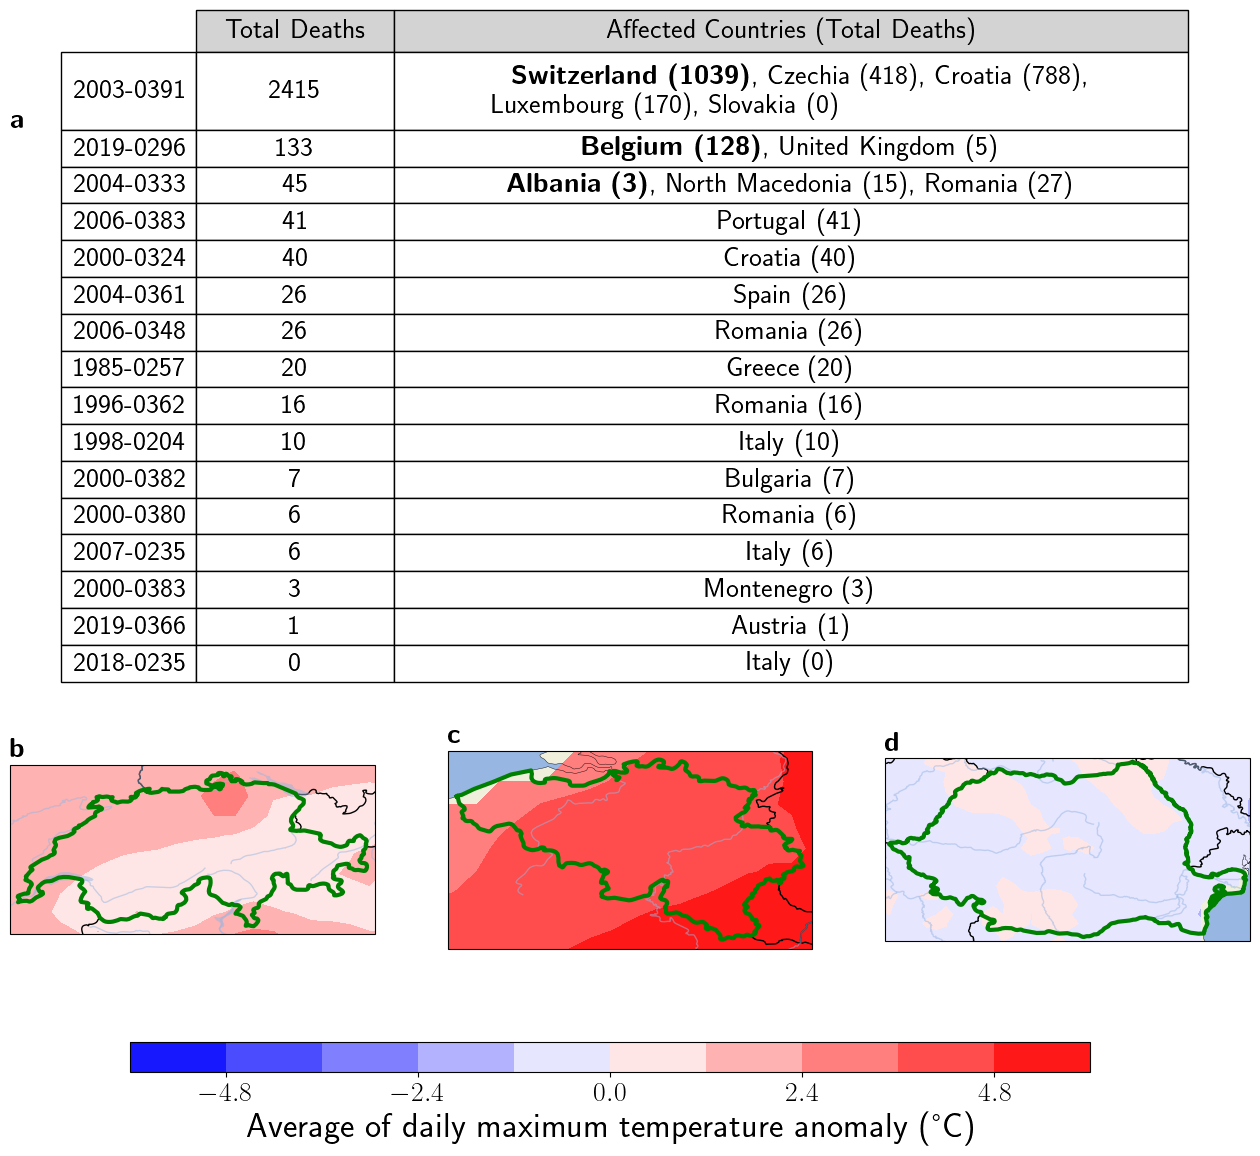

In [10]:
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)
land_mask = xr.open_dataset(join(read_directory,'ERA5','Mask',f"Mask_Europe_land_only_ERA5_0.25deg.nc"),engine='netcdf4').mask
if len(df_emdat_grouped)>=3 :
    plt.close()
    plt.rcParams['text.usetex'] = True
    fig_subplot = plt.figure(figsize=(16,12))
    ax1=fig_subplot.add_subplot(234,projection=ccrs.PlateCarree()).set_title('\\textbf{b}',loc='left',size=20)
    ax2=fig_subplot.add_subplot(235,projection=ccrs.PlateCarree()).set_title('\\textbf{c}',loc='left',size=20)
    ax3=fig_subplot.add_subplot(236,projection=ccrs.PlateCarree()).set_title('\\textbf{d}',loc='left',size=20)
    ax4=fig_subplot.add_subplot(211).set_title('\\textbf{a}',loc='left',size=20)
    min_val=0
    max_val=0
    plotted_var = [[]]*3
    sub_df = df_emdat_grouped[["Total Deaths","Affected Countries (Total Deaths)"]]
    for ax_count in range(3) :
        htw_ID = df_emdat_grouped.iloc[ax_count,2] # Get heatwave identifier to look for corresponding EM-DAT information
        country = df_emdat_undetected.loc[htw_ID,'Country']
        mask_country = xr.open_dataset(join(read_directory,"ERA5","Mask",f"Mask_{country_dict[country]}_ERA5_0.25deg.nc"),engine='netcdf4').mask
        mask_country['lat'] = da_temp.lat # Fix broken latitude
        mask_country['lon'] = da_temp.lon # Fix broken longitude
        year_event = int(df_emdat.loc[htw_ID,'Start Year'])
        if np.isnan(df_emdat.loc[htw_ID,'Start Day']) : # If Start Day is not recorded, start searching at 1st day of the month
            date_beg = pd.Timestamp(year_event, int(df_emdat.loc[htw_ID,'Start Month']), 1)
        else : # Otherwise, take recorded day and add flex_time_span to 
            date_beg = pd.Timestamp(year_event, int(df_emdat.loc[htw_ID,'Start Month']), int(df_emdat.loc[htw_ID,'Start Day'])) - pd.DateOffset(days=flex_time_span)

        if np.isnan(df_emdat.loc[htw_ID,'End Day']) : # If End Day is not recorded, keep searching until last day of the month
            date_end = pd.Timestamp(year_event, int(df_emdat.loc[htw_ID,'End Month']), 1)
            date_end = pd.offsets.MonthEnd().rollforward(date_end)
        else : # Otherwise, take recorded day and add flex_time_span
            date_end = pd.Timestamp(year_event, int(df_emdat.loc[htw_ID,'End Month']), int(df_emdat.loc[htw_ID,'End Day'])) + pd.DateOffset(days=flex_time_span)

        date_beg = cftime.DatetimeNoLeap(date_beg.year, date_beg.month, date_beg.day)
        date_end = cftime.DatetimeNoLeap(date_end.year, date_end.month, date_end.day)

        da_temp_event = da_temp.sel(time=slice(date_beg,date_end)) # Keep only values matching the period of EM-DAT event
        da_temp_event = da_temp_event.where(land_mask.data==0,drop=False)
        plotted_var[ax_count] = da_temp_event.mean(dim="time")
        da_temp_event = da_temp_event.where(mask_country==0,drop=False).mean(dim="time")
        min_val = min(min_val,min(np.floor(-np.abs(da_temp_event.min().data)),np.floor(-np.abs(da_temp_event.max().data))))
        max_val = max(max_val,max(np.ceil(np.abs(da_temp_event.min().data)),np.ceil(np.abs(da_temp_event.max().data))))
        
    the_levels=[0]*11#nb of color categories + 1
    for k in range(len(the_levels)):
        the_levels[k]=min_val+k*(max_val-min_val)/(len(the_levels)-1)
    ax_count=0 
    for ax in [ax1.axes,ax2.axes,ax3.axes] :
        htw_ID = df_emdat_grouped.iloc[ax_count,2] # Get heatwave identifier to look for corresponding EM-DAT information
        country = df_emdat_undetected.loc[htw_ID,'Country']
        CS1 = ax.contourf(da_temp.lon,da_temp.lat,plotted_var[ax_count],cmap='bwr',transform=ccrs.PlateCarree(), levels=the_levels)
        poly = df_countries.loc[df_countries['ADMIN'] == country]['geometry'].values[0]
        try :
            ax.plot(*poly.exterior.xy,'green',linewidth=3)
        except :#in case the country is not Polygon but MultiPolygon
            for geom in poly.geoms :
                ax.plot(*geom.exterior.xy,'green',linewidth=3)
        ax.set_extent([poly.bounds[0]-0.1,poly.bounds[2]+0.1,poly.bounds[1]-0.1,poly.bounds[3]+0.1])
        ax.add_feature(cfeature.BORDERS)
        ax.add_feature(cfeature.LAND)
        ax.add_feature(cfeature.OCEAN)
        ax.add_feature(cfeature.COASTLINE,linewidth=0.3)
        ax.add_feature(cfeature.LAKES, alpha=0.5)
        ax.add_feature(cfeature.RIVERS, alpha=0.5)
        ax_count+=1
    cax = plt.axes([0.2, 0.1, 0.6, 0.025])
    cbar = fig_subplot.colorbar(CS1,cax=cax,orientation='horizontal')
    cbar.set_label('Average of daily maximum temperature anomaly (°C)', rotation=0, size=25)
    cbar.ax.tick_params(labelsize=20)
    
    table = ax4.axes.table(cellText=sub_df.values,
            rowLabels=sub_df.index,
            colLabels=sub_df.columns,bbox=[0.15,-0.3,0.8,1.6],cellLoc='center',colWidths=[0.15,0.6])
    cellDict = table.get_celld()
    for i in range(0,len(sub_df.columns)):
        cellDict[(0,i)].set_height(.1)
        cellDict[(1,i)].set_height(5.5/30)
        for j in range(2,len(sub_df.values)+1):
            cellDict[(j,i)].set_height(2.6/30)
            if i==0 :
                cellDict[(j,-1)].set_height(2.6/30)
    cellDict[(0, 0)].set_facecolor("lightgray")
    cellDict[(0, 1)].set_facecolor("lightgray")
    cellDict[(1,-1)].set_height(5.5/30)
    ax4.axes.set_axis_off()
    table.auto_set_font_size(False)
    table.set_fontsize(20)
    plt.savefig(join(write_directory,"figs","Undetected.pdf"),dpi=1200)
    plt.show()

# Compute list of ISO alpha 3 country names for Table 5

In [11]:
df_events = pd.read_csv(join(write_directory,"df_htws_top_events_NOCHANGE.csv"),header=0,index_col=0)

In [12]:
country_dict_list = {'Russia':'Russian Federation','Bosnia_and_Herzegovina':'Bosnia and Herzegovina','Macedonia':'North Macedonia',
"United_Kingdom":"United Kingdom",'Turkey':'Türkiye','Moldova':'Moldova, Republic of'}

In [13]:
# Choose correct row index
country_list = df_events.loc[369,'Affected countries >10%'][1:].split(",")

alpha_3_list = ''
for country in country_list:
    # Correct country name if necessary
    if country in country_dict_list.keys():
        country = country_dict_list[country]
    # Get alpha-3 code
    alpha_3_list += f"{pycountry.countries.get(name=country).alpha_3}, "
print(alpha_3_list[:-2])    

RUS, UKR


# Show indices scores for different sensitivity configurations

### Show for one sensitivity configuration

In [14]:
df_scores = pd.read_csv(join(write_directory,"df_scores.csv"),index_col=0,header=0)

In [15]:
df_scores = df_scores[['R Pearson','AUC ROC','R2']].map(lambda x: f"{round((eval(x)['median']),2)} [{round((eval(x)['q5']),2)}; {round((eval(x)['q95']),2)}]",na_action='ignore')
df_scores.to_csv(join(write_directory,"df_scores_clean.csv"))

In [16]:
df_scores

,R Pearson,AUC ROC,R2
Intensity,0.43 [0.25; 0.63],0.63 [0.54; 0.72],0.2 [0.06; 0.41]
Spatial extent,0.66 [0.21; 0.92],0.64 [0.54; 0.73],0.45 [0.05; 0.85]
Duration,0.72 [0.1; 0.88],0.68 [0.59; 0.75],0.51 [0.02; 0.78]
Max,0.4 [0.24; 0.6],0.64 [0.54; 0.73],0.16 [0.06; 0.36]
Temp_sum,0.7 [0.16; 0.99],0.65 [0.56; 0.73],0.49 [0.02; 0.97]
HWMId_sum,0.7 [0.12; 0.99],0.7 [0.61; 0.78],0.49 [0.01; 0.97]
HWMId_mean,0.26 [0.01; 0.42],0.71 [0.62; 0.79],0.07 [0.0; 0.17]
Exposed_population,0.7 [0.42; 0.85],0.7 [0.62; 0.78],0.48 [0.18; 0.72]
Temp_pop,0.85 [0.54; 0.96],0.72 [0.64; 0.78],0.72 [0.29; 0.93]
HWMId_pop,0.86 [0.45; 0.98],0.74 [0.66; 0.82],0.74 [0.2; 0.95]


### Show for all sensitivity configurations

In [17]:
df_sensitivity = pd.read_csv(join("/home/user/These/extreme_htws_cc3d/Data","summary_detection_overlap_sensitivity.csv"),header=0,index_col=0)

In [18]:
array_col = [["AUC ROC","AUC ROC","AUC ROC","AUC ROC", "R pearson","R pearson","R pearson","R pearson", "R2","R2","R2","R2", 'EM-DAT match (max. 88)', 'nb detected cc3d'],
["Intensity", "HWMId_sum", "Exposed_population", "HWMId_pop",
"Intensity", "HWMId_sum", "Exposed_population", "HWMId_pop",
"Intensity", "HWMId_sum", "Exposed_population", "HWMId_pop", "", ""]]
array_row = [["average","daily_var","daily_var","daily_var",
"threshold_value","threshold_value","nb_days","nb_days","nb_days","nb_days",
"end_year_ref","end_year_ref","connectivity","connectivity"]
,['','tx','tg','tn',90,95,3,4,5,6,2005,2021,26,18]]
tuples_row = list(zip(*array_row))
tuples_col = list(zip(*array_col))
df_scores_sensi_CI = pd.DataFrame(index=pd.MultiIndex.from_tuples(tuples_row),columns=pd.MultiIndex.from_tuples(tuples_col),dtype=object)
sub_df_sensitivity = df_sensitivity[df_sensitivity['end_year']==2021]
idx_dict = {'daily_var':['tx','tg','tn'], 'threshold_value':[90,95], 'nb_days':[3,4,5,6],'end_year_ref':[2005,2021],'connectivity':[26,18]}

for index in ["Intensity", "HWMId_sum", "Exposed_population", "HWMId_pop"]:
    df_scores_sensi_CI.loc[('average',''),("R pearson",index)] = f"{round(np.nanmedian(sub_df_sensitivity.loc[:,f'pearson_R_{index}']),2)} {[float(round(np.nanpercentile(sub_df_sensitivity.loc[:,f'pearson_R_{index}'],5),2)),float(round(np.nanpercentile(sub_df_sensitivity.loc[:,f'pearson_R_{index}'],95),2))]}"
    df_scores_sensi_CI.loc[('average',''),("AUC ROC",index)] = f"{round(np.nanmedian(sub_df_sensitivity.loc[:,f'auc_roc_{index}']),2)} {[float(round(np.nanpercentile(sub_df_sensitivity.loc[:,f'auc_roc_{index}'],5),2)),float(round(np.nanpercentile(sub_df_sensitivity.loc[:,f'auc_roc_{index}'],95),2))]}"
    df_scores_sensi_CI.loc[('average',''),("R2",index)] = f"{round(np.nanmedian(sub_df_sensitivity.loc[:,f'R2_{index}']),2)} {[float(round(np.nanpercentile(sub_df_sensitivity.loc[:,f'R2_{index}'],5),2)),float(round(np.nanpercentile(sub_df_sensitivity.loc[:,f'R2_{index}'],95),2))]}"
match_distrib = np.array(sub_df_sensitivity['nb_emdat_matching_htws'])
df_scores_sensi_CI.loc[('average',''),'EM-DAT match (max. 88)'] = f"{round(np.nanmedian(match_distrib),2)} {[float(round(np.nanpercentile(match_distrib,5),2)),float(round(np.nanpercentile(match_distrib,95),2))]}"

nb_detected_distrib = np.array(sub_df_sensitivity['nb_detected_htws'])
df_scores_sensi_CI.loc[('average',''),'nb detected cc3d'] = f"{round(np.nanmedian(nb_detected_distrib),2)} {[float(round(np.nanpercentile(nb_detected_distrib,5),2)),float(round(np.nanpercentile(nb_detected_distrib,95),2))]}"

for var in idx_dict.keys():
    for val in idx_dict[var]:
        sub_df = sub_df_sensitivity[sub_df_sensitivity[var]==val]
        distrib = [0]*len(sub_df)
        for index in ["Intensity", "HWMId_sum", "Exposed_population", "HWMId_pop"]:
            df_scores_sensi_CI.loc[(var,val),("R pearson",index)] = f"{round(np.nanmedian(sub_df.loc[:,f'pearson_R_{index}']),2)} {[float(round(np.nanpercentile(sub_df.loc[:,f'pearson_R_{index}'],5),2)),float(round(np.nanpercentile(sub_df.loc[:,f'pearson_R_{index}'],95),2))]}"
            df_scores_sensi_CI.loc[(var,val),("AUC ROC",index)] = f"{round(np.nanmedian(sub_df.loc[:,f'auc_roc_{index}']),2)} {[float(round(np.nanpercentile(sub_df.loc[:,f'auc_roc_{index}'],5),2)),float(round(np.nanpercentile(sub_df.loc[:,f'auc_roc_{index}'],95),2))]}"
            df_scores_sensi_CI.loc[(var,val),("R2",index)] = f"{round(np.nanmedian(sub_df.loc[:,f'R2_{index}']),2)} {[float(round(np.nanpercentile(sub_df.loc[:,f'R2_{index}'],5),2)),float(round(np.nanpercentile(sub_df.loc[:,f'R2_{index}'],95),2))]}"
        match_distrib = np.array(sub_df['nb_emdat_matching_htws'])
        df_scores_sensi_CI.loc[(var,val),('EM-DAT match (max. 88)','')] = f"{round(np.nanmedian(match_distrib),2)} {[float(round(np.nanpercentile(match_distrib,5),2)),float(round(np.nanpercentile(match_distrib,95),2))]}"
        nb_detected_distrib = np.array(sub_df['nb_detected_htws'])
        df_scores_sensi_CI.loc[(var,val),('nb detected cc3d','')] = f"{round(np.nanmedian(nb_detected_distrib),2)} {[float(round(np.nanpercentile(nb_detected_distrib,5),2)),float(round(np.nanpercentile(nb_detected_distrib,95),2))]}"

df_scores_sensi_CI.to_csv(join(read_directory,"indices_scores_summary_sensitivity.csv"))

In [19]:
df_scores_sensi_CI

AUC ROC                                        \
                              Intensity          HWMId_sum Exposed_population   
average               0.62 [0.52, 0.69]  0.72 [0.61, 0.79]   0.71 [0.47, 0.8]   
daily_var       tx    0.64 [0.56, 0.69]   0.74 [0.7, 0.79]  0.75 [0.68, 0.82]   
                tg     0.63 [0.53, 0.7]  0.73 [0.61, 0.79]  0.68 [0.51, 0.74]   
                tn    0.58 [0.53, 0.69]   0.69 [0.6, 0.83]   0.64 [0.46, 0.8]   
threshold_value 90    0.64 [0.59, 0.71]  0.75 [0.69, 0.83]   0.74 [0.67, 0.8]   
                95    0.59 [0.51, 0.66]    0.7 [0.6, 0.77]   0.64 [0.46, 0.8]   
nb_days         3     0.64 [0.58, 0.75]  0.76 [0.68, 0.82]  0.75 [0.62, 0.81]   
                4     0.61 [0.52, 0.67]  0.73 [0.65, 0.82]  0.72 [0.58, 0.82]   
                5     0.61 [0.54, 0.68]  0.71 [0.61, 0.76]  0.69 [0.48, 0.76]   
                6     0.59 [0.49, 0.68]    0.7 [0.6, 0.76]  0.68 [0.46, 0.75]   
end_year_ref    2005  0.62 [0.52, 0.71]  0.73 [0.62, 0.83]    0.7 [0.55, 0.8]   
                2021  0.62 [0.56, 0.68]  0.71 [0.61, 0.76]  0.71 [0.46, 0.76]   
connectivity    26    0.62 [0.53, 0.69]   0.72 [0.61, 0.8]   0.71 [0.48, 0.8]   
                18    0.62 [0.53, 0.69]  0.72 [0.61, 0.79]    0.7 [0.48, 0.8]   

                                                 R pearson                     \
                              HWMId_pop          Intensity          HWMId_sum   
average               0.71 [0.55, 0.82]  0.25 [0.09, 0.48]  0.75 [0.67, 0.86]   
daily_var       tx    0.77 [0.71, 0.82]    0.4 [0.3, 0.63]   0.7 [0.67, 0.75]   
                tg     0.7 [0.54, 0.77]  0.18 [0.11, 0.38]  0.79 [0.74, 0.87]   
                tn     0.66 [0.53, 0.8]  0.19 [0.07, 0.34]  0.77 [0.65, 0.84]   
threshold_value 90    0.76 [0.67, 0.82]  0.25 [0.08, 0.41]  0.76 [0.69, 0.86]   
                95    0.66 [0.51, 0.81]  0.27 [0.14, 0.57]  0.75 [0.67, 0.85]   
nb_days         3     0.77 [0.63, 0.82]  0.15 [0.08, 0.41]    0.76 [0.7, 0.8]   
                4     0.74 [0.61, 0.82]  0.24 [0.09, 0.44]  0.74 [0.66, 0.82]   
                5     0.71 [0.52, 0.78]  0.29 [0.11, 0.53]  0.78 [0.68, 0.86]   
                6       0.7 [0.52, 0.8]  0.29 [0.18, 0.66]  0.76 [0.63, 0.88]   
end_year_ref    2005  0.72 [0.57, 0.82]  0.29 [0.14, 0.43]  0.74 [0.65, 0.82]   
                2021  0.71 [0.51, 0.79]  0.19 [0.08, 0.57]   0.78 [0.7, 0.87]   
connectivity    26    0.71 [0.56, 0.82]   0.25 [0.1, 0.47]  0.75 [0.68, 0.86]   
                18    0.71 [0.56, 0.81]  0.25 [0.09, 0.48]  0.75 [0.67, 0.86]   

                                                                           R2  \
                     Exposed_population          HWMId_pop          Intensity   
average               0.51 [0.35, 0.76]  0.68 [0.49, 0.89]  0.09 [0.02, 0.22]   
daily_var       tx    0.59 [0.44, 0.78]  0.82 [0.74, 0.91]  0.16 [0.09, 0.41]   
                tg    0.46 [0.35, 0.76]  0.65 [0.57, 0.83]  0.04 [0.02, 0.16]   
                tn    0.45 [0.31, 0.61]  0.58 [0.48, 0.74]  0.05 [0.01, 0.12]   
threshold_value 90    0.45 [0.35, 0.66]  0.63 [0.48, 0.85]  0.07 [0.01, 0.17]   
                95    0.57 [0.34, 0.77]  0.74 [0.52, 0.89]  0.09 [0.02, 0.33]   
nb_days         3      0.43 [0.38, 0.6]    0.62 [0.5, 0.8]  0.03 [0.01, 0.17]   
                4     0.47 [0.34, 0.67]  0.66 [0.49, 0.84]   0.07 [0.02, 0.2]   
                5     0.54 [0.41, 0.76]  0.74 [0.55, 0.88]   0.09 [0.03, 0.3]   
                6     0.62 [0.28, 0.79]  0.73 [0.49, 0.91]  0.09 [0.04, 0.46]   
end_year_ref    2005  0.45 [0.33, 0.62]  0.65 [0.48, 0.85]  0.09 [0.03, 0.19]   
                2021  0.58 [0.39, 0.77]  0.72 [0.56, 0.91]  0.06 [0.01, 0.33]   
connectivity    26    0.51 [0.34, 0.76]  0.68 [0.51, 0.88]  0.09 [0.02, 0.22]   
                18    0.51 [0.36, 0.76]  0.68 [0.49, 0.88]  0.09 [0.02, 0.23]   

                                                                               \
                              HWMId_sum Exposed_population  

### Compute best indices for all sensitivity analysis

In [20]:
array_col = [["AUC ROC","AUC ROC","AUC ROC","AUC ROC", "R pearson","R pearson","R pearson","R pearson", "R2","R2","R2","R2", 'EM-DAT match (max. 88)', 'nb detected cc3d'],
["Intensity", "HWMId_sum", "Exposed_population", "HWMId_pop",
"Intensity", "HWMId_sum", "Exposed_population", "HWMId_pop",
"Intensity", "HWMId_sum", "Exposed_population", "HWMId_pop", "", ""]]
array_row = [["average","daily_var","daily_var","daily_var",
"threshold_value","threshold_value","nb_days","nb_days","nb_days","nb_days",
"end_year_ref","end_year_ref","connectivity","connectivity"]
,['','tx','tg','tn',90,95,3,4,5,6,2005,2021,26,18]]
tuples_row = list(zip(*array_row))
tuples_col = list(zip(*array_col))

df_scores_sensi_percent = pd.DataFrame(index=pd.MultiIndex.from_tuples(tuples_row),columns=pd.MultiIndex.from_tuples(tuples_col),dtype=object)

sub_df_sensitivity = df_sensitivity[df_sensitivity['end_year']==2021]
idx_dict = {'daily_var':['tx','tg','tn'], 'threshold_value':[90,95], 'nb_days':[3,4,5,6],'end_year_ref':[2005,2021],'connectivity':[26,18]}

for index in ["Intensity", "HWMId_sum", "Exposed_population", "HWMId_pop"]:
    df_scores_sensi_percent.loc[('average',''),("R pearson",index)] = f"{round(100*len(sub_df_sensitivity[sub_df_sensitivity["best_pearson_R_idx"]==index])/len(sub_df_sensitivity),1)} %"
    df_scores_sensi_percent.loc[('average',''),("AUC ROC",index)] = f"{round(100*len(sub_df_sensitivity[sub_df_sensitivity["best_auc_roc_idx"]==index])/len(sub_df_sensitivity),1)} %"
    df_scores_sensi_percent.loc[('average',''),("R2",index)] = f"{round(100*len(sub_df_sensitivity[sub_df_sensitivity["best_R2_idx"]==index])/len(sub_df_sensitivity),1)} %"

match_distrib = np.array(sub_df_sensitivity['nb_emdat_matching_htws'])
df_scores_sensi_percent.loc[('average',''),'EM-DAT match (max. 88)'] = f"{round(np.nanmedian(match_distrib),2)} {[float(round(np.nanpercentile(match_distrib,5),2)),float(round(np.nanpercentile(match_distrib,95),2))]}"

nb_detected_distrib = np.array(sub_df_sensitivity['nb_detected_htws'])
df_scores_sensi_percent.loc[('average',''),'nb detected cc3d'] = f"{round(np.nanmedian(nb_detected_distrib),2)} {[float(round(np.nanpercentile(nb_detected_distrib,5),2)),float(round(np.nanpercentile(nb_detected_distrib,95),2))]}"


for var in idx_dict.keys():
    for val in idx_dict[var]:
        sub_df = sub_df_sensitivity[sub_df_sensitivity[var]==val]
        distrib = [0]*len(sub_df)
        for index in ["Intensity", "HWMId_sum", "Exposed_population", "HWMId_pop"]:
            df_scores_sensi_percent.loc[(var,val),("R pearson",index)] = f"{round(100*len(sub_df[sub_df["best_pearson_R_idx"]==index])/len(sub_df),1)} %"
            df_scores_sensi_percent.loc[(var,val),("AUC ROC",index)] = f"{round(100*len(sub_df[sub_df["best_auc_roc_idx"]==index])/len(sub_df),1)} %"
            df_scores_sensi_percent.loc[(var,val),("R2",index)] = f"{round(100*len(sub_df[sub_df["best_R2_idx"]==index])/len(sub_df),1)} %"
        match_distrib = np.array(sub_df['nb_emdat_matching_htws'])
        df_scores_sensi_percent.loc[(var,val),('EM-DAT match (max. 88)','')] = f"{round(np.nanmedian(match_distrib),2)} {[float(round(np.nanpercentile(match_distrib,5),2)),float(round(np.nanpercentile(match_distrib,95),2))]}"
        nb_detected_distrib = np.array(sub_df['nb_detected_htws'])
        df_scores_sensi_percent.loc[(var,val),('nb detected cc3d','')] = f"{round(np.nanmedian(nb_detected_distrib),2)} {[float(round(np.nanpercentile(nb_detected_distrib,5),2)),float(round(np.nanpercentile(nb_detected_distrib,95),2))]}"

df_scores_sensi_percent.to_csv(join(read_directory,"best_indices_percent_summary_sensitivity.csv"))

In [21]:
df_scores_sensi_percent

AUC ROC                                         \
                     Intensity HWMId_sum Exposed_population HWMId_pop   
average                  0.0 %    61.5 %              9.4 %    29.2 %   
daily_var       tx       0.0 %     3.1 %              9.4 %    87.5 %   
                tg       0.0 %   100.0 %              0.0 %     0.0 %   
                tn       0.0 %    81.2 %             18.8 %     0.0 %   
threshold_value 90       0.0 %    54.2 %             14.6 %    31.2 %   
                95       0.0 %    68.8 %              4.2 %    27.1 %   
nb_days         3        0.0 %    66.7 %              8.3 %    25.0 %   
                4        0.0 %    58.3 %             12.5 %    29.2 %   
                5        0.0 %    58.3 %              8.3 %    33.3 %   
                6        0.0 %    62.5 %              8.3 %    29.2 %   
end_year_ref    2005     0.0 %    64.6 %              6.2 %    29.2 %   
                2021     0.0 %    58.3 %             12.5 %    29.2 %   
connectivity    26       0.0 %    60.4 %              8.3 %    31.2 %   
                18       0.0 %    62.5 %             10.4 %    27.1 %   

                     R pearson                                         \
                     Intensity HWMId_sum Exposed_population HWMId_pop   
average                  0.0 %    66.7 %              0.0 %    33.3 %   
daily_var       tx       0.0 %     0.0 %              0.0 %   100.0 %   
                tg       0.0 %   100.0 %              0.0 %     0.0 %   
                tn       0.0 %   100.0 %              0.0 %     0.0 %   
threshold_value 90       0.0 %    66.7 %              0.0 %    33.3 %   
                95       0.0 %    66.7 %              0.0 %    33.3 %   
nb_days         3        0.0 %    66.7 %              0.0 %    33.3 %   
                4        0.0 %    66.7 %              0.0 %    33.3 %   
                5        0.0 %    66.7 %              0.0 %    33.3 %   
                6        0.0 %    66.7 %              0.0 %    33.3 %   
end_year_ref    2005     0.0 %    66.7 %              0.0 %    33.3 %   
                2021     0.0 %    66.7 %              0.0 %    33.3 %   
connectivity    26       0.0 %    66.7 %              0.0 %    33.3 %   
                18       0.0 %    66.7 %              0.0 %    33.3 %   

                            R2                                         \
                     Intensity HWMId_sum Exposed_population HWMId_pop   
average                  0.0 %    66.7 %              0.0 %    33.3 %   
daily_var       tx       0.0 %     0.0 %              0.0 %   100.0 %   
                tg       0.0 %   100.0 %              0.0 %     0.0 %   
                tn       0.0 %   100.0 %              0.0 %     0.0 %   
threshold_value 90       0.0 %    66.7 %              0.0 %    33.3 %   
                95       0.0 %    66.7 %              0.0 %    33.3 %   
nb_days         3        0.0 %    66.7 %              0.0 %    33.3 %   
                4        0.0 %    66.7 %              0.0 %    33.3 %   
                5        0.0 %    66.7 %              0.0 %    33.3 %   
                6        0.0 %    66.7 %              0.0 %    33.3 %   
end_year_ref    2005     0.0 %    66.7 %              0.0 %    33.3 %   
                2021     0.0 %    66.7 %              0.0 %    33.3 %   
connectivity    26       0.0 %    66.7 %              0.0 %    33.3 %   
                18       0.0 %    66.7 %              0.0 %    33.3 %   

                     EM-DAT match (max. 88)        nb detected cc3d  
                                                                     
average                   53.5 [24.0, 85.0]   279.0 [137.0, 373.25]  
daily_var       tx       73.5 [40.7, 86.45]   269.5 [114.8, 415.45]  
                tg        50.5 [28.4, 69.6]   288.5 [153.5, 365.85]  
                tn        45.5 [22.2, 67.8]   273.0 [140.95, 339.9]  
threshold_value 90        65.5 [41.0, 86.0]    328.0 [235.0, 414.3]  
                95        

# Trends

In [22]:
# Trends are computed for 1975-2024 so have to change end_year and write_directory
end_year = 2024 # end of the studied period, default 2021

write_directory = join(read_directory,f"ERA5_{temp_variable}_{daily_var}_{threshold_value}{name_dict_threshold[relative_threshold]}_connec_{connectivity}_{nb_days}days_flex_{flex_time_span}d_{start_year}_{end_year}_ref_{start_year_ref}_{end_year_ref}{'_anomaly'*anomaly}_merge_{merge_method}")

In [23]:
pop_file_path = join(read_directory,"GHS-POP","GHS_POP_R2023A_1975_2030_ERA5_Europe_grid.nc")
land_mask = xr.open_dataset(join(read_directory,'ERA5','Mask',f"Mask_Europe_land_only_ERA5_0.25deg.nc"),engine='netcdf4').mask
ds_cell_area = xr.open_dataset(join(read_directory,"ERA5","ERA5_Europe_cellarea.nc"),engine='netcdf4') # Area of each grid cell, in m²
da_cell_area = ds_cell_area.cell_area/1e6 # Load DataArray and convert to km²
area_Europe = da_cell_area.where(land_mask==0).sum().data
print('area_Europe',area_Europe)
ds_pop = xr.open_dataset(join(pop_file_path), engine='netcdf4') # Population count, need to convert to density
da_pop = ds_pop.Band1
pop_Europe = da_pop.where(land_mask==0).sum(dim=("lat","lon"))

area_Europe 8553667.612384018


In [24]:
df_htws = pd.read_csv(join(read_directory,"ERA5_t2m_tx_95th_connec_26_4days_flex_3d_1975_2024_ref_1975_2021_anomaly_merge_weighted","df_htws_step3.csv"),header=0,index_col=0)
print(df_htws['HWMId_pop'].mean())

146575808.7705309


### Show trends for one configuration of parameters

In [25]:
# Load Mann-Kendall trend results 
with open(join(write_directory,"mk_result.json"), mode='r') as f:
    mk_result = json.load(f)

df_mk_result = pd.json_normalize(mk_result)
df_mk_result = df_mk_result.set_index('_row')

# Create functions to compute relevant trends
def per_decade(x):
    return x*10
def thousands_per_decade(x):
    return 10*x/1e3
def millions_per_decade(x):
    return 10*x/1e6
def percent_Europe(x,area_Europe=area_Europe):
    return 10*100*x/area_Europe

# Create dictionary to match index with function
func_dict = {"Frequency":per_decade, "Intensity":per_decade, "Max":per_decade, "Spatial extent":percent_Europe, "Duration":per_decade, 
                "HWMId_sum":thousands_per_decade,
                "Exposed_population":millions_per_decade,"Exposed_population (relative)":per_decade,
                "HWMId_pop":millions_per_decade}

# Create dictionary to handle units of different index trends
unit_dict = {"Frequency":"Events/decade", "Intensity":"°C/decade", "Max":"°C/decade", "Spatial extent":"% of Europe area/decade", "Duration":"days/decade", "HWMId_sum":"10^3 IQR-km²/decade",
                "Exposed_population":"10^6 ppl/decade", "Exposed_population (relative)":"% of European population/decade",
                 "HWMId_pop":"10^6 IQR-persons/decade"}

df_mk_result = df_mk_result[["slope","lcl","ucl",'p','ss']]
df_mk_result["unit"] = None
for i in df_mk_result.index:
    slope = func_dict[i](df_mk_result.loc[i,"slope"])
    df_mk_result.loc[i,"slope"] = round(slope,2)
    lcl = func_dict[i](df_mk_result.loc[i,"lcl"])
    df_mk_result.loc[i,"lcl"] = round(lcl,2)
    ucl = func_dict[i](df_mk_result.loc[i,"ucl"])
    df_mk_result.loc[i,"ucl"] = round(ucl,2)
    df_mk_result.loc[i,"unit"] = unit_dict[i]
df_mk_result.rename_axis(index="Index").to_csv(join(write_directory,"trends.csv"))

In [26]:
df_mk_result.rename_axis(index="Index")

,slope,lcl,ucl,p,ss,unit
Index,,,,,,
Frequency,1.11,0.54,1.65,0.001693,95,Events/decade
Intensity,0.05,0.01,0.09,0.054065,0,°C/decade
Spatial extent,0.37,0.18,0.59,0.000617,95,% of Europe area/decade
Duration,0.47,0.00,0.87,0.010813,95,days/decade
Max,0.23,0.08,0.36,0.007101,95,°C/decade
HWMId_sum,85.50,29.94,151.73,0.007044,95,10^3 IQR-km²/decade
Exposed_population,3.06,1.58,4.86,0.000198,95,10^6 ppl/decade
HWMId_pop,5.39,1.79,10.01,0.000904,95,10^6 IQR-persons/decade
Exposed_population (relative),0.40,0.19,0.65,0.000606,95,% of European population/decade


### Summarize trends for all configurations of parameters

In [27]:
# Create functions to compute relevant trends
def per_decade(x):
    return x*10
def thousands_per_decade(x):
    return 10*x/1e3
def millions_per_decade(x):
    return 10*x/1e6
def percent_Europe(x,area_Europe=area_Europe):
    return 10*100*x/area_Europe

# Create dictionary to match index with function
func_dict = {"Frequency":per_decade, "Intensity":per_decade, "Max":per_decade, "Spatial extent":percent_Europe, "Duration":per_decade, 
                "HWMId_sum":thousands_per_decade,
                "Exposed_population":millions_per_decade,"Exposed_population (relative)":per_decade,
                "HWMId_pop":millions_per_decade}

# Create dictionary to handle units of different index trends
unit_dict = {"Frequency":"Events/decade", "Intensity":"°C/decade", "Max":"°C/decade", "Spatial extent":"% of Europe area/decade", "Duration":"days/decade", "HWMId_sum":"10^3 IQR-km²/decade",
                "Exposed_population":"10^6 ppl/decade", "Exposed_population (relative)":"% of European population/decade",
                 "HWMId_pop":"10^6 IQR-persons/decade"}

trend_indices = ['Frequency', 'Intensity', 'Max','Spatial extent', 'Duration', 'Exposed_population',
'Exposed_population (relative)', 'HWMId_sum','HWMId_pop']
 
array_row = [["unit","average","daily_var","daily_var","daily_var",
"threshold_value","threshold_value","nb_days","nb_days","nb_days","nb_days",
"end_year_ref","end_year_ref","connectivity","connectivity"]
,['','','tx','tg','tn',90,95,3,4,5,6,2005,2021,26,18]]
tuples = list(zip(*array_row))
df_stats_trends = pd.DataFrame(index=pd.MultiIndex.from_tuples(tuples),columns=trend_indices,dtype=object)
sub_df_sensitivity = df_sensitivity[df_sensitivity['end_year']==2024]
idx_dict = {'daily_var':['tx','tg','tn'], 'threshold_value':[90,95], 'nb_days':[3,4,5,6],'end_year_ref':[2005,2021],'connectivity':[26,18]}

for index in df_stats_trends.columns:
    trend_distrib = sub_df_sensitivity[f'trend_{index}'].map(lambda x: func_dict[index](eval(x)['median']),na_action='ignore')
    df_stats_trends.loc[('average',''),index] = f"{round(np.nanmedian(trend_distrib),2)} {[float(round(np.nanpercentile(trend_distrib,5),2)),float(round(np.nanpercentile(trend_distrib,95),2))]}"
    df_stats_trends.loc[('unit',''),index] = unit_dict[index]

for var in idx_dict.keys():
    for val in idx_dict[var]:
        sub_df = sub_df_sensitivity[sub_df_sensitivity[var]==val]
        distrib = [0]*len(sub_df)
        for index in df_stats_trends.columns:
            trend_distrib = sub_df[f'trend_{index}'].map(lambda x: func_dict[index](eval(x)['median']),na_action='ignore')
            df_stats_trends.loc[(var,val),index] = f"{round(np.nanmedian(trend_distrib),2)} {[float(round(np.nanpercentile(trend_distrib,5),2)),float(round(np.nanpercentile(trend_distrib,95),2))]}"
df_stats_trends.to_csv(join(read_directory,"trends_summary_sensitivity.csv"))            

In [28]:
df_stats_trends

Frequency            Intensity  \
unit                       Events/decade            °C/decade   
average               0.99 [-0.05, 1.46]   0.01 [-0.04, 0.08]   
daily_var       tx     0.7 [-0.36, 1.34]    0.05 [0.01, 0.13]   
                tg    1.18 [-0.28, 1.52]   -0.0 [-0.04, 0.04]   
                tn      1.05 [0.0, 1.47]   -0.0 [-0.04, 0.05]   
threshold_value 90     0.7 [-0.62, 1.24]  -0.01 [-0.04, 0.08]   
                95     1.22 [0.66, 1.59]   0.02 [-0.01, 0.13]   
nb_days         3     0.58 [-0.77, 1.35]   -0.0 [-0.04, 0.06]   
                4        1.11 [0.0, 1.4]   0.01 [-0.04, 0.07]   
                5      1.06 [0.43, 1.64]   0.02 [-0.05, 0.12]   
                6      1.21 [0.67, 1.55]   0.04 [-0.03, 0.12]   
end_year_ref    2005  0.77 [-0.62, 1.59]   0.02 [-0.01, 0.13]   
                2021   1.05 [0.37, 1.29]   0.01 [-0.04, 0.06]   
connectivity    26    0.99 [-0.14, 1.45]   0.01 [-0.04, 0.08]   
                18      0.99 [0.0, 1.45]   0.02 [-0.04, 0.08]   

                                     Max           Spatial extent  \
unit                           °C/decade  % of Europe area/decade   
average               0.17 [-0.04, 0.36]       0.11 [-0.01, 0.31]   
daily_var       tx     0.24 [0.13, 0.47]         0.17 [0.02, 0.4]   
                tg     0.1 [-0.08, 0.26]         0.1 [0.03, 0.28]   
                tn      0.12 [0.0, 0.25]       0.08 [-0.08, 0.19]   
threshold_value 90    0.06 [-0.07, 0.28]       0.11 [-0.01, 0.26]   
                95       0.2 [0.1, 0.45]        0.15 [0.03, 0.37]   
nb_days         3     0.08 [-0.06, 0.25]       0.21 [-0.05, 0.41]   
                4     0.16 [-0.03, 0.34]        0.13 [0.06, 0.36]   
                5     0.16 [-0.07, 0.45]        0.1 [-0.07, 0.28]   
                6      0.23 [0.03, 0.42]       0.06 [-0.01, 0.24]   
end_year_ref    2005   0.17 [0.02, 0.45]       0.09 [-0.07, 0.28]   
                2021  0.16 [-0.07, 0.28]        0.15 [0.05, 0.37]   
connectivity    26    0.17 [-0.03, 0.34]         0.11 [-0.0, 0.3]   
                18    0.17 [-0.03, 0.34]         0.11 [-0.0, 0.3]   

                               Duration  Exposed_population  \
unit                        days/decade     10^6 ppl/decade   
average                0.67 [0.33, 1.5]  0.45 [-0.03, 2.72]   
daily_var       tx    0.59 [0.32, 0.82]    1.85 [0.48, 3.2]   
                tg    0.69 [0.36, 1.22]   0.22 [0.01, 1.63]   
                tn    0.96 [0.53, 1.73]  0.22 [-0.04, 0.77]   
threshold_value 90    0.62 [0.31, 1.19]  0.29 [-0.03, 2.29]   
                95    0.74 [0.47, 1.51]  0.65 [-0.01, 3.08]   
nb_days         3     0.54 [0.32, 1.46]   0.68 [-0.0, 3.25]   
                4       0.7 [0.47, 1.4]   0.68 [0.03, 2.91]   
                5     0.68 [0.25, 1.24]  0.22 [-0.04, 2.56]   
                6      1.0 [0.56, 1.78]  0.29 [-0.02, 1.42]   
end_year_ref    2005  0.96 [0.47, 1.67]  0.27 [-0.03, 2.29]   
                2021  0.58 [0.31, 1.13]   0.63 [0.14, 2.73]   
connectivity    26    0.68 [0.38, 1.48]  0.45 [-0.03, 2.72]   
                18    0.67 [0.33, 1.48]  0.47 [-0.03, 2.72]   

                        Exposed_population (relative)            HWMId_sum  \
unit                  % of European population/decade  10^3 IQR-km²/decade   
average                            0.04 [-0.01, 0.36]  22.51 [2.71, 74.12]   
daily_var       tx                  0.22 [0.04, 0.41]  26.34 [6.62, 89.75]   
                tg                  0.02 [-0.01, 0.2]  11.01 [1.69, 58.62]   
                tn                 0.02 [-0.01, 0.08]   22.51 [3.1, 38.91]   
threshold_value 90                 0.02 [-0.01, 0.28]  13.82 [1.96, 42.99]   
                95                   0.07 [-0.0, 0.4]  28.11 [4.18, 86.56]   
nb_days         3                  0.06 [-0.01, 0.41]  28.51 [2.88, 69.51]   
                4                  0.08 [-0.01, 0.38]  24.99 [7.91, 79.99]   
                5                  0.02 [-0.01, 0.33]  16.06 [3.57, 85.34]   
                6 

# Compare different ways of distributing EM-DAT impact among several matching CC3D heatwaves

In [29]:
array_col = [["AUC ROC","AUC ROC","AUC ROC", "R Pearson","R Pearson","R Pearson", "R2","R2","R2"],
["strongest", "equal", "weighted",
"strongest", "equal", "weighted",
"strongest", "equal", "weighted"]]
array_row = ["Intensity","Spatial extent","Duration","Max","HWMId_sum","Exposed_population","HWMId_pop"]
tuples_col = list(zip(*array_col))
compare_df = pd.DataFrame(index=array_row,columns=pd.MultiIndex.from_tuples(tuples_col),dtype=object)

In [30]:
for method in ["strongest", "equal", "weighted"]:
    df_method = pd.read_csv(join("Data",f"ERA5_t2m_tx_95th_connec_26_4days_flex_3d_1975_2021_ref_1975_2021_anomaly_merge_{method}","df_scores.csv"),header=0,index_col=0)
    df_overlap = pd.read_csv(join("Data",f"ERA5_t2m_tx_95th_connec_26_4days_flex_3d_1975_2021_ref_1975_2021_anomaly_merge_{method}","df_emdat_overlap.csv"),header=0,index_col=0)
    for score in ["AUC ROC","R Pearson","R2"]:
        for index in compare_df.index:
            compare_df.loc[index,(score,method)] = f"{round(eval(df_method.loc[index,score])['median'],2)} [{round(eval(df_method.loc[index,score])['q5'],2)}; {round(eval(df_method.loc[index,score])['q95'],2)}]"

In [31]:
compare_df

AUC ROC                                        \
                            strongest              equal           weighted   
Intensity           0.65 [0.55; 0.74]  0.63 [0.54; 0.71]  0.63 [0.54; 0.72]   
Spatial extent      0.65 [0.55; 0.75]  0.64 [0.55; 0.73]  0.64 [0.54; 0.73]   
Duration              0.7 [0.6; 0.77]   0.68 [0.6; 0.76]  0.68 [0.59; 0.75]   
Max                 0.68 [0.59; 0.78]  0.64 [0.54; 0.73]  0.64 [0.54; 0.73]   
HWMId_sum           0.74 [0.65; 0.82]   0.7 [0.61; 0.79]   0.7 [0.61; 0.78]   
Exposed_population  0.72 [0.63; 0.81]  0.71 [0.63; 0.78]   0.7 [0.62; 0.78]   
HWMId_pop            0.78 [0.7; 0.85]  0.74 [0.66; 0.82]  0.74 [0.66; 0.82]   

                            R Pearson                                         \
                            strongest               equal           weighted   
Intensity           0.44 [0.22; 0.66]   0.33 [0.02; 0.52]  0.43 [0.25; 0.63]   
Spatial extent      0.68 [0.21; 0.92]  0.35 [-0.07; 0.64]  0.66 [0.21; 0.92]   
Duration             0.73 [0.15; 0.9]  0.43 [-0.16; 0.71]   0.72 [0.1; 0.88]   
Max                 0.39 [0.23; 0.58]   0.29 [-0.14; 0.5]    0.4 [0.24; 0.6]   
HWMId_sum           0.71 [0.12; 0.99]  0.32 [-0.13; 0.77]   0.7 [0.12; 0.99]   
Exposed_population   0.7 [0.44; 0.85]  0.45 [-0.02; 0.66]   0.7 [0.42; 0.85]   
HWMId_pop           0.88 [0.49; 0.98]  0.54 [-0.03; 0.88]  0.86 [0.45; 0.98]   

                                   R2                                        
                            strongest              equal           weighted  
Intensity            0.2 [0.05; 0.45]   0.11 [0.0; 0.27]   0.2 [0.06; 0.41]  
Spatial extent      0.44 [0.04; 0.85]   0.13 [0.0; 0.42]  0.45 [0.05; 0.85]  
Duration             0.54 [0.03; 0.8]  0.17 [0.01; 0.45]  0.51 [0.02; 0.78]  
Max                 0.15 [0.05; 0.36]   0.08 [0.0; 0.26]  0.16 [0.06; 0.36]  
HWMId_sum           0.52 [0.02; 0.98]   0.1 [0.01; 0.56]  0.49 [0.01; 0.97]  
Exposed_population   0.5 [0.21; 0.73]    0.2 [0.0; 0.46]  0.48 [0.18; 0.72]  
HWMId_pop            0.77 [0.3; 0.96]  0.28 [0.01; 0.76]   0.74 [0.2; 0.95]

In [32]:
compare_df.to_csv(join(read_directory,"merge_methods_comparison.csv"))